In [15]:
from typing import Annotated

from langchain_openai import ChatOpenAI
# from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [16]:
load_dotenv()

True

In [17]:
# llm = ChatOpenAI(model="gpt-4.1-mini")

In [18]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [19]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [20]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



In [21]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

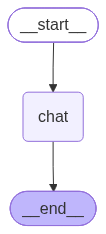

In [22]:
app

In [23]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [24]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='a99f4b23-8c91-4496-ac20-78349f27902a')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='fc09ca31fd8862e7c2e9c39651efac29')]}

In [25]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [26]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [27]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [28]:
print(final_result["messages"][-1].content)

Imagine you're at the top of a mountain, and you want to get to the bottom. The problem is, it's foggy, so you can't see the whole mountain. You can only see a little bit around you.

**Gradient Descent** is like taking small steps down the mountain, one at a time. At each step, you look around and say, "Which direction is downhill?" Then, you take a small step in that direction.

You keep doing this, step by step, until you reach the bottom of the mountain. The idea is that, even though you can't see the whole mountain, you can still find your way down by taking small steps in the right direction.

In machine learning, the "mountain" is like a mathematical function that we want to minimize (or maximize). The "steps" are like adjustments to the model's parameters. Gradient descent is a way to adjust those parameters, one step at a time, to find the best solution.

The key idea is to follow the **gradient**, which is like a sign that points downhill. By following the gradient, we can ta